In [1]:
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import re
import json

In [2]:
MAX_LEN = 128
BATCH_SIZE = 64
EMB_DIM = 256
LATENT_DIM = 128
N_HEADS = 8
FF_DIM = 512
NUM_LAYERS = 4
VOCAB_SPECIAL = ['<pad>', '<bos>', '<eos>', '<unk>']

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем устройство: {DEVICE}")
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

Используем устройство: cuda
True
12.8
NVIDIA GeForce RTX 3060 Laptop GPU


In [3]:
# Загружаем датасет
df = pd.read_csv("data/polyOne_aa.csv")

with open("data/user_request_dataset/property_mapping.json", "r", encoding="utf-8") as f:
    json_data = json.load(f)
    PROPERTY_MAPPING = json_data["PROPERTY_MAPPING"] 

# Теперь NUM_FEATURES будет содержать все ключи из PROPERTY_MAPPING
NUM_FEATURES = list(PROPERTY_MAPPING.keys())
print(f"Количество признаков: {len(NUM_FEATURES)}")
print(NUM_FEATURES[:5])  # Показываем первые 5 признаков для проверки

Количество признаков: 37
['Egc', 'Egb', 'Eib', 'CED', 'Ei']


In [26]:
from polymer_property_prediction_dataset_and_tokenizer import PolymerDataset, SmilesTokenizer

In [5]:
# Создаем и обучаем токенизатор
tokenizer = SmilesTokenizer(max_len=MAX_LEN)
tokenizer.fit(df['smiles'].tolist())
VOCAB_SIZE = len(tokenizer.vocab)
print(f"Размер словаря: {VOCAB_SIZE}")

Словарь построен: 61 токенов
Размер словаря: 61


In [6]:
# Разделяем данные
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Создаем датасеты
train_dataset = PolymerDataset(train_df, tokenizer, NUM_FEATURES, fit_scaler=True)
val_dataset = PolymerDataset(val_df, tokenizer, NUM_FEATURES, scaler=train_dataset.scaler)
test_dataset = PolymerDataset(test_df, tokenizer, NUM_FEATURES, scaler=train_dataset.scaler)

# Создаем DataLoader'ы
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Train: 400000, Val: 50000, Test: 50000


In [7]:
class PositionalEncoding(nn.Module):
    """Синусоидальное позиционное кодирование"""
    
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

In [8]:
class SmilesPropertyPredictor(nn.Module):
    """
    Transformer-based модель для предсказания свойств полимеров по SMILES
    
    Архитектура:
    1. Embedding + Positional Encoding
    2. Transformer Encoder (N слоев)
    3. Global Average Pooling
    4. MLP Head для каждого свойства
    """
    
    def __init__(
        self,
        vocab_size,
        num_properties,
        emb_dim=256,
        n_heads=8,
        ff_dim=512,
        num_layers=4,
        dropout=0.1,
        max_len=128
    ):
        super().__init__()
        
        self.emb_dim = emb_dim
        self.num_properties = num_properties
        
        # Embedding слой
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.pos_encoding = PositionalEncoding(emb_dim, max_len, dropout)
        
        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True  # Pre-LN для лучшей стабильности
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Layer Norm после transformer
        self.ln = nn.LayerNorm(emb_dim)
        
        # MLP Head для предсказания свойств
        self.property_head = nn.Sequential(
            nn.Linear(emb_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, ff_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim // 2, num_properties),
            nn.Sigmoid()  # Выход в [0, 1] для нормализованных свойств
        )
        
        # Инициализация весов
        self._init_weights()
    
    def _init_weights(self):
        """Xavier инициализация"""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward(self, input_ids, attention_mask=None):
        """
        Args:
            input_ids: [batch, seq_len] - токенизированные SMILES
            attention_mask: [batch, seq_len] - маска padding'а
        
        Returns:
            properties: [batch, num_properties] - предсказанные свойства
        """
        # Создаем маску для padding токенов
        if attention_mask is None:
            attention_mask = (input_ids != 0)  # padding_idx = 0
        
        # Маска для transformer (True = игнорировать)
        src_key_padding_mask = ~attention_mask
        
        # Embedding + Positional Encoding
        x = self.embedding(input_ids)  # [batch, seq, emb_dim]
        x = self.pos_encoding(x)
        
        # Transformer Encoder
        x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        x = self.ln(x)
        
        # Global Average Pooling (только по не-padding токенам)
        mask_expanded = attention_mask.unsqueeze(-1).float()  # [batch, seq, 1]
        x = (x * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1e-9)
        
        # Предсказание свойств
        properties = self.property_head(x)
        
        return properties

In [9]:
# Создаем модель
model = SmilesPropertyPredictor(
    vocab_size=VOCAB_SIZE,
    num_properties=len(NUM_FEATURES),
    emb_dim=EMB_DIM,
    n_heads=N_HEADS,
    ff_dim=FF_DIM,
    num_layers=NUM_LAYERS,
    dropout=0.1,
    max_len=MAX_LEN
).to(DEVICE)

model = model.to(DEVICE)  # <-- ДОБАВЬТЕ ЭТУ СТРОКУ
print(f"Модель перемещена на: {next(model.parameters()).device}")
print(f"Модель на устройстве: {next(model.parameters()).device}")
print(f"GPU память выделено: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

# Проверка памяти GPU
if DEVICE.type == 'cuda':
    print(f"Использовано GPU памяти: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
    
# Подсчет параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")

Модель перемещена на: cuda:0
Модель на устройстве: cuda:0
GPU память выделено: 0.01 GB
Использовано GPU памяти: 0.01 GB
Всего параметров: 2,396,965
Обучаемых параметров: 2,396,965


C:\drivers\python_inter\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [10]:
class MaskedMSELoss(nn.Module):
    """MSE Loss с маской для пропущенных значений"""
    
    def __init__(self):
        super().__init__()
    
    def forward(self, predictions, targets, mask):
        """
        Args:
            predictions: [batch, num_properties]
            targets: [batch, num_properties]
            mask: [batch, num_properties] - True для валидных значений
        """
        # Вычисляем MSE только для валидных значений
        squared_error = (predictions - targets) ** 2
        masked_error = squared_error * mask.float()
        
        # Среднее по валидным элементам
        loss = masked_error.sum() / mask.float().sum().clamp(min=1)
        
        return loss

In [11]:
def train_epoch(model, loader, optimizer, criterion, scheduler=None, scaler=None):
    """Одна эпоха обучения"""
    model.train()
    total_loss = 0
    num_batches = 0
    
    pbar = tqdm(loader, desc="Training", leave=False)
    
    for batch in pbar:
        input_ids = batch['input_ids'].to(DEVICE)
        properties = batch['properties'].to(DEVICE)
        mask = batch['mask'].to(DEVICE)
        
        optimizer.zero_grad()
        
        # Mixed Precision Training
        if scaler is not None:
            with torch.cuda.amp.autocast():
                predictions = model(input_ids)
                loss = criterion(predictions, properties, mask)
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            predictions = model(input_ids)
            loss = criterion(predictions, properties, mask)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        if scheduler is not None:
            scheduler.step()
        
        total_loss += loss.item()
        num_batches += 1
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / num_batches

In [12]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    """Оценка модели с минимальным переносом на CPU"""
    model.eval()
    device = next(model.parameters()).device
    
    total_loss = 0.0
    num_batches = 0
    
    all_preds = []
    all_targets = []
    all_masks = []
    
    for batch in tqdm(loader, desc="Evaluating", leave=False):
        input_ids = batch['input_ids'].to(device)
        properties = batch['properties'].to(device)
        mask = batch['mask'].to(device)
        
        predictions = model(input_ids)
        loss = criterion(predictions, properties, mask)
        
        total_loss += loss.item()
        num_batches += 1
        
        # Собираем всё на GPU
        all_preds.append(predictions)
        all_targets.append(properties)
        all_masks.append(mask)
    
    # Конкатенируем на GPU
    preds = torch.cat(all_preds, dim=0)
    targets = torch.cat(all_targets, dim=0)
    masks = torch.cat(all_masks, dim=0)
    
    # Вычисляем R2 на GPU
    r2_scores = {}
    avg_r2 = 0.0
    
    for i, prop in enumerate(NUM_FEATURES):
        valid_mask = masks[:, i].bool()
        if valid_mask.sum() > 1:  # Нужно минимум 2 валидных значения
            p = preds[:, i][valid_mask]
            t = targets[:, i][valid_mask]
            
            ss_res = torch.sum((t - p) ** 2)
            ss_tot = torch.sum((t - torch.mean(t)) ** 2)
            r2 = 1 - ss_res / torch.clamp(ss_tot, min=1e-9)
            r2_scores[prop] = r2.item()
            avg_r2 += r2.item()
        else:
            r2_scores[prop] = float('nan')
    
    if r2_scores:
        avg_r2 = avg_r2 / len(r2_scores)
    else:
        avg_r2 = float('nan')
    
    return total_loss / num_batches, r2_scores, avg_r2

In [13]:
def compute_metrics_per_property(model, loader, scaler, property_cols):
    """Вычисление метрик с минимальным переносом на CPU"""
    model.eval()
    device = next(model.parameters()).device
    
    all_preds = []
    all_targets = []
    all_masks = []
    
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            predictions = model(input_ids)
            
            # Собираем всё на GPU
            all_preds.append(predictions)
            all_targets.append(batch['properties'].to(device))
            all_masks.append(batch['mask'].to(device))
    
    # Конкатенируем на GPU
    preds = torch.cat(all_preds, dim=0)
    targets = torch.cat(all_targets, dim=0)
    masks = torch.cat(all_masks, dim=0)
    
    # Денормализация на GPU (если scaler доступен как тензоры)
    if scaler is not None:
        # Предполагаем, что scaler сохранен как тензоры на GPU
        data_range = torch.tensor(scaler.data_range_, device=device, dtype=torch.float32)
        data_min = torch.tensor(scaler.data_min_, device=device, dtype=torch.float32)
        
        preds = preds * data_range + data_min
        targets = targets * data_range + data_min
    
    metrics = {}
    for i, prop in enumerate(property_cols):
        valid_mask = masks[:, i].bool()
        if valid_mask.sum() > 0:
            p = preds[:, i][valid_mask]
            t = targets[:, i][valid_mask]
            
            # Все вычисления на GPU
            mae = torch.mean(torch.abs(p - t)).item()
            rmse = torch.sqrt(torch.mean((p - t) ** 2)).item()
            
            # R2 score на GPU
            ss_res = torch.sum((t - p) ** 2)
            ss_tot = torch.sum((t - torch.mean(t)) ** 2)
            r2 = (1 - ss_res / torch.clamp(ss_tot, min=1e-9)).item()
            
            metrics[prop] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    
    # Переносим результаты на CPU только в конце
    return metrics

In [14]:
# Гиперпараметры
EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
WARMUP_STEPS = 500

# Optimizer & Scheduler
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# Cosine Annealing с Warmup
total_steps = len(train_loader) * EPOCHS

def lr_lambda(step):
    if step < WARMUP_STEPS:
        return step / WARMUP_STEPS
    progress = (step - WARMUP_STEPS) / (total_steps - WARMUP_STEPS)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Loss & Scaler для mixed precision
criterion = MaskedMSELoss()
scaler = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None

# История обучения
history = {
    'train_loss': [],
    'val_loss': [],
    'val_r2': [],
    'lr': []
}

# Best model tracking
best_val_loss = float('inf')
best_model_state = None
patience = 15
patience_counter = 0

C:\Users\evgen\AppData\Local\Temp\ipykernel_22232\2957170128.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None


In [15]:
print("=" * 60)
print("Начало обучения")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    
    # Training
    train_loss = train_epoch(model, train_loader, optimizer, criterion, scheduler, scaler)
    
    # Validation
    val_loss, r2_scores, avg_r2 = evaluate(model, val_loader, criterion)
    
    # Сохраняем историю
    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_r2'].append(avg_r2)
    history['lr'].append(current_lr)
    
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Avg R²: {avg_r2:.4f} | LR: {current_lr:.2e}")
    
    # Early Stopping & Best Model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print("✓ Новый лучший результат!")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping после {epoch} эпох")
            break

# Загружаем лучшую модель
model.load_state_dict(best_model_state)
print(f"\nЛучшая модель загружена (val_loss: {best_val_loss:.4f})")

Начало обучения

Epoch 1/20


Training:   0%|          | 0/6250 [00:00<?, ?it/s]E:\Code\Poliforge\Polyforge-AI\Polyforge-AI\polymer_property_prediction_dataset_and_tokenizer.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(encoded, dtype=torch.long),
C:\Users\evgen\AppData\Local\Temp\ipykernel_22232\3963534768.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train Loss: 0.0058 | Val Loss: 0.0038 | Avg R²: 0.3937 | LR: 9.95e-05
✓ Новый лучший результат!

Epoch 2/20


Train Loss: 0.0033 | Val Loss: 0.0030 | Avg R²: 0.5528 | LR: 9.77e-05
✓ Новый лучший результат!

Epoch 3/20


Train Loss: 0.0027 | Val Loss: 0.0025 | Avg R²: 0.6246 | LR: 9.48e-05
✓ Новый лучший результат!

Epoch 4/20


...

Train Loss: 0.0009 | Val Loss: 0.0008 | Avg R²: 0.8644 | LR: 9.62e-06

Epoch 17/20


Train Loss: 0.0009 | Val Loss: 0.0008 | Avg R²: 0.8656 | LR: 5.49e-06
✓ Новый лучший результат!

Epoch 18/20


Train Loss: 0.0008 | Val Loss: 0.0008 | Avg R²: 0.8691 | LR: 2.47e-06
✓ Новый лучший результат!

Epoch 19/20


Train Loss: 0.0008 | Val Loss: 0.0008 | Avg R²: 0.8682 | LR: 6.21e-07
✓ Новый лучший результат!

Epoch 20/20


Train Loss: 0.0008 | Val Loss: 0.0008 | Avg R²: 0.8688 | LR: 0.00e+00
✓ Новый лучший результат!

Лучшая модель загружена (val_loss: 0.0008)


In [16]:
import pickle

SAVE_DIR = "models/smiles_property_predictor"
os.makedirs(SAVE_DIR, exist_ok=True)

# Сохраняем модель
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'vocab_size': VOCAB_SIZE,
        'num_properties': len(NUM_FEATURES),
        'emb_dim': EMB_DIM,
        'n_heads': N_HEADS,
        'ff_dim': FF_DIM,
        'num_layers': NUM_LAYERS,
        'max_len': MAX_LEN
    },
    'property_cols': NUM_FEATURES,
    'best_val_loss': best_val_loss,
    'history': history
}, f"{SAVE_DIR}/model.pt")

# Сохраняем токенизатор
tokenizer.save(f"{SAVE_DIR}/tokenizer.json")

# Сохраняем scaler
with open(f"{SAVE_DIR}/scaler.pkl", 'wb') as f:
    pickle.dump(train_dataset.scaler, f)

print(f"Модель сохранена в {SAVE_DIR}/")

Модель сохранена в models/smiles_property_predictor/


In [53]:
from rdkit.Chem.Draw import rdMolDraw2D
import matplotlib.pyplot as plt
from rdkit import Chem


class SmilesPropertyPredictorInference:
    """Класс для инференса модели"""
    
    def __init__(self, model_dir):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Загружаем компоненты
        checkpoint = torch.load(
            f"{model_dir}/model.pt", 
            map_location=self.device,
            weights_only=False  # Временное решение
        )
        self.tokenizer = SmilesTokenizer.load(f"{model_dir}/tokenizer.json")
        
        with open(f"{model_dir}/scaler.pkl", 'rb') as f:
            self.scaler = pickle.load(f)
        
        self.property_cols = checkpoint['property_cols']
        config = checkpoint['model_config']
        
        # Создаем и загружаем модель
        self.model = SmilesPropertyPredictor(**config).to(self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.eval()
    
    @torch.no_grad()
    def predict(self, smiles_list):
        if isinstance(smiles_list, str):
            smiles_list = [smiles_list]
        
        # Токенизация с принудительной конвертацией в целые числа
        encoded = []
        for s in smiles_list:
            seq = self.tokenizer.encode(s)
            # Конвертируем все элементы в целые числа
            clean_seq = []
            for x in seq:
                if torch.is_tensor(x):
                    clean_seq.append(x.item())
                elif isinstance(x, (np.ndarray, list, tuple)):
                    clean_seq.append(int(x[0]) if len(x) > 0 else 0)
                else:
                    clean_seq.append(int(x))
            encoded.append(clean_seq)
        
        # Проверяем, что все последовательности одинаковой длины
        seq_lengths = [len(seq) for seq in encoded]
        if len(set(seq_lengths)) != 1:
            print(f"Warning: sequences have different lengths: {seq_lengths}")
            max_len = max(seq_lengths)
            padded_encoded = []
            pad_id = self.tokenizer.vocab['<pad>']
            if torch.is_tensor(pad_id):
                pad_id = pad_id.item()
            elif isinstance(pad_id, (np.ndarray, list, tuple)):
                pad_id = int(pad_id[0]) if len(pad_id) > 0 else 0
            else:
                pad_id = int(pad_id)
                
            for seq in encoded:
                if len(seq) < max_len:
                    padded_seq = seq + [pad_id] * (max_len - len(seq))
                else:
                    padded_seq = seq[:max_len]
                padded_encoded.append(padded_seq)
            encoded = padded_encoded
    
        # Создаем тензор
        input_ids = torch.tensor(encoded, dtype=torch.long).to(self.device)
        
        # Предсказание
        predictions = self.model(input_ids).cpu().numpy()
        
        # Денормализация
        predictions = predictions * self.scaler.data_range_ + self.scaler.data_min_
        
        # Создаем DataFrame
        result = pd.DataFrame(predictions, columns=self.property_cols)
        result.insert(0, 'smiles', smiles_list)
        
        return result
    
    def predict_with_advanced_visualization(self, smiles_input):
        """Предсказание с продвинутой визуализацией"""
        if isinstance(smiles_input, list):
            smiles_str = smiles_input[0]
        else:
            smiles_str = smiles_input
        
        result = self.predict([smiles_str])
        
        mol = Chem.MolFromSmiles(smiles_str)
        if mol is not None:
            # Создаем большой холст для детальной визуализации
            d = rdMolDraw2D.MolDraw2DCairo(1000, 1000)  # 1000x1000 пикселей
            d.drawOptions().addAtomIndices = False  # Не показывать индексы атомов
            d.drawOptions().bondLineWidth = 2  # Толщина связей
            d.DrawMolecule(mol)
            d.FinishDrawing()
            
            # Конвертируем в изображение для отображения в Jupyter
            from IPython.display import Image, display
            img_data = d.GetDrawingText()
            with open('/tmp/temp_mol.png', 'wb') as f:
                f.write(img_data)
            display(Image(filename='/tmp/temp_mol.png'))
        else:
            print(f"Внимание: Не удалось создать молекулу из SMILES: {smiles_str}")
        
        # Вывод свойств (как в предыдущих версиях)
        print(f"\nПредсказанные свойства для {smiles_str}:")
        print("-" * 40)
        for col in self.property_cols:
            value = result[col].values[0]
            readable_name = PROPERTY_MAPPING.get(col, col)
            print(f"{readable_name}: {value:.4f}")
        
        return result

In [34]:
# Загружаем модель для инференса
predictor = SmilesPropertyPredictorInference(SAVE_DIR)

# Примеры предсказаний
test_smiles = [
    "[*]CCCc1cccc(-c2c(Br)cc(-c3c(Br)cc(-c4cccc(N(C)CCC[*])c4)cc3Br)cc2Br)c1"
]

print("Примеры предсказаний")

results = predictor.predict(test_smiles)

# Настраиваем pandas для красивого вывода
pd.set_option('display.max_columns', None)  # Показать все колонки
pd.set_option('display.width', None)        # Автоматическая ширина
pd.set_option('display.precision', 4)       # 4 знака после запятой
pd.set_option('display.float_format', '{:.4f}'.format)  # Формат чисел

Примеры предсказаний


C:\drivers\python_inter\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [35]:
results

,smiles,Egc,Egb,Eib,CED,Ei,Eea,Eat,nc,ne,Xc,Xe,epse_6.0,epsc,epse_3.0,epse_1.78,epse_15.0,epse_4.0,epse_5.0,epse_2.0,epse_9.0,epse_7.0,epsb,TSb,TSy,YM,permCH4,permCO2,permH2,permO2,permN2,permHe,Cp,Td,Tg,Tm,rho,LOI
0,[*]CCCc1cccc(-c2c(Br)cc(-c3c(Br)cc(-c4cccc(N(C...,3.9980,3.7295,3.7824,125.6565,5.8774,2.0865,-5.5119,2.1533,1.7288,76.5703,71.3398,4.1124,5.3798,4.5446,4.9285,2.9921,4.3679,4.2373,4.8379,3.7067,3.9837,4.8306,68.9102,54.6989,2043.9360,-0.2925,0.6182,5.4601,0.1146,-0.2105,8.5087,1.7113,684.1718,493.6727,573.3072,1.6066,58.4342


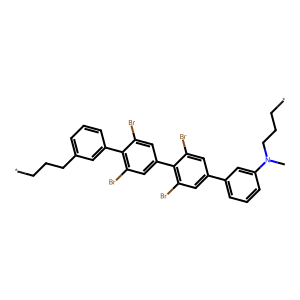


Предсказанные свойства для [*]CCCc1cccc(-c2c(Br)cc(-c3c(Br)cc(-c4cccc(N(C)CCC[*])c4)cc3Br)cc2Br)c1:
----------------------------------------
Group Contribution Energy (kJ/mol): 3.9980
Bond Energy Contribution (kJ/mol): 3.7295
Internal Bond Energy (kJ/mol): 3.7824
Cohesive Energy Density (J/cm³): 125.6565
Ionization Energy (eV): 5.8774
Electron Affinity (eV): 2.0865
Atomization Energy (kJ/mol): -5.5119
Number of Carbon Atoms: 2.1533
Number of Electrons: 1.7288
Crystallinity Index (%): 76.5703
Crosslinking Density (mol/m³): 71.3398
Dielectric Constant at 6.0 GHz: 4.1124
Static Dielectric Constant (0 Hz): 5.3798
Dielectric Constant at 3.0 GHz: 4.5446
Dielectric Constant at 1.78 GHz: 4.9285
Dielectric Constant at 15.0 GHz: 2.9921
Dielectric Constant at 4.0 GHz: 4.3679
Dielectric Constant at 5.0 GHz: 4.2373
Dielectric Constant at 2.0 GHz: 4.8379
Dielectric Constant at 9.0 GHz: 3.7067
Dielectric Constant at 7.0 GHz: 3.9837
Breakdown Dielectric Strength (kV/mm): 4.8306
Tensile Strength at Br

,smiles,Egc,Egb,Eib,CED,Ei,Eea,Eat,nc,ne,Xc,Xe,epse_6.0,epsc,epse_3.0,epse_1.78,epse_15.0,epse_4.0,epse_5.0,epse_2.0,epse_9.0,epse_7.0,epsb,TSb,TSy,YM,permCH4,permCO2,permH2,permO2,permN2,permHe,Cp,Td,Tg,Tm,rho,LOI
0,[*]CCCc1cccc(-c2c(Br)cc(-c3c(Br)cc(-c4cccc(N(C...,3.9980,3.7295,3.7824,125.6565,5.8774,2.0865,-5.5119,2.1533,1.7288,76.5703,71.3398,4.1124,5.3798,4.5446,4.9285,2.9921,4.3679,4.2373,4.8379,3.7067,3.9837,4.8306,68.9102,54.6989,2043.9360,-0.2925,0.6182,5.4601,0.1146,-0.2105,8.5087,1.7113,684.1718,493.6727,573.3072,1.6066,58.4342


In [54]:
# Детальное предсказание с визуализацией
predictor.predict_with_visualization(test_smiles[0])